<a href="https://colab.research.google.com/github/iav2002/Assignment_Advanced_Topics_In_DeepLearning/blob/main/Part3_DQN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 3: DQN on Warehouse Navigation

We train a Deep Q-Network agent to navigate a 5x5 warehouse grid and reach a pallet, using the visual embeddings learned in Part 2 as part of the state representation.

The investigation has two threads.  First we compare three DQN variants in an additive fashion:
1. A vanilla version,
2. Experience replay,
3. Before + Target network on top.

Afterwards we run an ablation on the reward function we designed, since reward shaping is where the real design comes to play.

We start from a baseline Reward function provitional and then we wil improve it along our investigation, as well as improving the complexity of the gridd

In [1]:
import sys, os, json, random, time
from pathlib import Path
from collections import deque

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = Path('/content/drive/MyDrive/Colab Notebooks/AdvancedDL')
EMB_PATH = DRIVE_ROOT / 'embeddings' / 'mean_embeddings.npy'
ENV_PATH = DRIVE_ROOT / 'WarehouseEnv.py'
RESULTS_ROOT = DRIVE_ROOT / 'results_part3'
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

assert EMB_PATH.exists(), f"missing: {EMB_PATH}"
assert ENV_PATH.exists(), f"missing: {ENV_PATH}"
print("paths ok")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
paths ok


In [3]:
# add Drive folder to path so the warehouse file can be imported
sys.path.insert(0, str(DRIVE_ROOT))

# clear any cached version because in case of overwriting
if 'WarehouseEnv' in sys.modules:
    del sys.modules['WarehouseEnv']

import gymnasium
from WarehouseEnv import WarehouseEnv
print("env imported ok")

env imported ok


## Loading the Part 2 embeddings

The mean embeddings come from Part 2's best ResNet50 model (Variant C of Experiment 1, 99.05% test accuracy). They are stored as a dict keyed by class name, each pointing to a 2048-dim vector.

The environment looks them up by integer ID (0=floor, 1=wall, 2=pallet, 3=sign), so we remap the keys before passing the dict in.

In [4]:
emb_str = np.load(EMB_PATH, allow_pickle=True).item()
print("classes:", list(emb_str.keys()))
print("vector dim:", emb_str['floor'].shape)

# remap str keys to int IDs the env expects
NAME_TO_ID = {'floor': 0, 'wall': 1, 'pallet': 2, 'sign': 3}
emb = {NAME_TO_ID[k]: v.astype(np.float32) for k, v in emb_str.items()}
print("remapped keys:", list(emb.keys()))

classes: ['floor', 'wall', 'pallet', 'sign']
vector dim: (2048,)
remapped keys: [0, 1, 2, 3]


## Grid layout

We start with a minimal but non trivial 5x5 grid: the agent spawns at (0,0), the pallet sits at (4,4), and a single wall at the center forces the agent to learn a detour rather than going straight diagonal. No signs in this first version. (will change with commits)

When the experiments turn out too easy or the embeddings end up not contributing meaningfully, we'll come back here to make it harder.

Coordinate convention: `grid_map[row, col]` for the matrix, but the agent's position is stored as `(x, y)` where x is column and y is row, matching the env's movement code (LLMs detection).

In [5]:
# 0=floor, 1=wall, 2=pallet, 3=sign
# sign at (2,2) sits in the central corridor the agent has to cross to reach
# the pallet. With this layout the embedding of sign appears in the agent's
# state when it walks over the corridor, which gives R4 (sign shaping) something
# meaningful to test in the ablation study
GRID = [
    [0, 0, 1, 0, 0],
    [1, 0, 1, 0, 1],
    [0, 0, 3, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 0, 2],
]

sym = {0:'.', 1:'#', 2:'P', 3:'S'}
for row in GRID:
    print(' '.join(sym[c] for c in row))

. . # . .
# . # . #
. . S . .
. # # # .
. . . . P


In [6]:
#SMOKE TEST
env = WarehouseEnv(grid_map=GRID, embeddings_dict=emb)

print("action space:", env.action_space)
print("obs space shape:", env.observation_space.shape)
print("target coords:", env.target_coords)

obs, info = env.reset()
print("initial obs shape:", obs.shape)
print("first 5 dims (xy + emb start):", obs[:5])

# also test one step to confirm the reward function works
obs, reward, term, trunc, info = env.step(3)  # action 3 = right
print(f"after step right: pos={env.agent_pos}, reward={reward}, term={term}")

action space: Discrete(4)
obs space shape: (2050,)
target coords: [4 4]
initial obs shape: (2050,)
first 5 dims (xy + emb start): [0.         0.         1.1220449  0.06864746 0.02758316]
after step right: pos=[1 0], reward=-0.05, term=False


## Random baseline

Before training anything, we measure how a random agent performs. This is just a sanity check that the env runs end-to-end across many episodes, and also a reference for future variations (the real ones).

We define three per episode metrics that we'll reuse in along the notebook: success (1 if the pallet was reached, 0 otherwise), episode length in steps, and total accumulated reward. Episodes are short to make them fast

New "harder" grid takes 8 steps to solve, and we are giving 100 MAx steps, to reduce accuracy but have also a "baseline of results"

In [7]:
MAX_STEPS = 100  # cap per episode, to solve it takes 8

def run_random(env, n_episodes=100, seed=0):
    rng = np.random.default_rng(seed)
    successes, lengths, rewards = [], [], []

    for ep in range(n_episodes):
        env.reset()
        ep_reward = 0.0
        for t in range(MAX_STEPS):
            action = rng.integers(0, env.action_space.n)
            _, r, term, trunc, _ = env.step(int(action))
            ep_reward += r
            if term or trunc:
                break
        successes.append(int(term))
        lengths.append(t + 1)
        rewards.append(ep_reward)

    return np.array(successes), np.array(lengths), np.array(rewards)

# run it
succ, lens, rews = run_random(env, n_episodes=100, seed=0)

print(f"Success rate:   {succ.mean():.2%}")
print(f"Avg ep length:  {lens.mean():.1f} steps")
print(f"Avg ep reward:  {rews.mean():.2f}")
print(f"Episodes that reached the pallet: {succ.sum()}/100")

Success rate:   42.00%
Avg ep length:  85.6 steps
Avg ep reward:  -23.78
Episodes that reached the pallet: 42/100


## Reading the baseline

We modify our grid to enforce a "harder" one, where we will expect a better improvement as we go along with the experiments

## V1: Vanilla DQN

At every step, we take an action, observe the result, and immediately do one gradient step on that single transition.

We run V1 with three different random seeds to get a sense of how much variance there is between runs.

In [8]:
class QNetwork(nn.Module):
    """
    Maps a state vector to Q-values for each action.
    Output convention (matches WarehouseEnv action_space):
      index 0 -> Up
      index 1 -> Down
      index 2 -> Left
      index 3 -> Right

    Two hidden layers with ReLU. Small network because the input is small
    (2 coords + 2048 embedding) and the action space is tiny (4).
    """
    def __init__(self, state_dim, action_dim, hidden=128):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


# quick sanity check that the net builds and produces the right shape
state_dim = env.observation_space.shape[0]   # 2050
action_dim = env.action_space.n              # 4
net = QNetwork(state_dim, action_dim).to(device)

# pass a dummy obs through it and check output shape
dummy = torch.zeros(1, state_dim).to(device)
out = net(dummy)
print(f"Net output shape: {out.shape}  (expected [1, 4])")
print(f"Trainable params: {sum(p.numel() for p in net.parameters()):,}")

Net output shape: torch.Size([1, 4])  (expected [1, 4])
Trainable params: 279,556


In [9]:
# hyperparameters: kept close to the FrozenLake DQN lab as a starting point
# we'll revisit if training is unstable or too slow
EPISODES = 500            # how many episodes per training run
LR = 1e-3                 # learning rate for the optimizer
GAMMA = 0.99              # discount factor on future rewards
EPS_START = 1.0           # start fully exploring
EPS_END = 0.05            # but never go below 5% exploration
EPS_DECAY = 0.995         # multiply epsilon by this each episode

def train_v1(env, seed=0, episodes=EPISODES, verbose=True):
    """
    Vanilla DQN one gradient step per env step on the latest transition.
    No replay buffer, no target net. Returns per episode metrics.
    """
    # seeding everything for reproducibility within a run
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    # build a fresh net and optimizer for this run
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n
    net = QNetwork(state_dim, action_dim).to(device)
    opt = optim.Adam(net.parameters(), lr=LR)

    eps = EPS_START
    successes, lengths, total_rewards = [], [], []

    for ep in range(episodes):
        obs, _ = env.reset()
        ep_reward = 0.0

        for t in range(MAX_STEPS):
            # epsilon greedy action selection
            if random.random() < eps:
                action = random.randint(0, action_dim - 1)
            else:
                # pick argmax of Q-values from the net
                with torch.no_grad():
                    s = torch.from_numpy(obs).float().unsqueeze(0).to(device)
                    action = int(net(s).argmax(dim=1).item())

            # take the action
            next_obs, reward, term, trunc, _ = env.step(action)
            ep_reward += reward
            done = term or trunc

            # vanilla update one gradient step on this single transition
            # this is the part that V2 will replace with batch sampling from a buffer
            s = torch.from_numpy(obs).float().unsqueeze(0).to(device)
            ns = torch.from_numpy(next_obs).float().unsqueeze(0).to(device)
            a = torch.tensor([[action]], device=device)
            r = torch.tensor([[reward]], dtype=torch.float32, device=device)
            d = torch.tensor([[float(done)]], device=device)

            # Q(s, a) predicted by the net
            q_pred = net(s).gather(1, a)

            # target: r + gamma * max_a' Q(s', a'), zeroed if episode ended
            # using the same net for the target is what makes it "vanilla" (and unstable)
            with torch.no_grad():
                q_next = net(ns).max(dim=1, keepdim=True)[0]
                q_target = r + GAMMA * q_next * (1 - d)

            # MSE loss + step
            loss = F.mse_loss(q_pred, q_target)
            opt.zero_grad()
            loss.backward()
            opt.step()

            obs = next_obs
            if done:
                break

        # log episode outcome
        successes.append(int(term))
        lengths.append(t + 1)
        total_rewards.append(ep_reward)

        # decay epsilon (but not below the minimum)
        eps = max(EPS_END, eps * EPS_DECAY)

        # progress every 100 episodes
        if verbose and (ep + 1) % 100 == 0:
            recent = np.mean(successes[-100:])
            print(f"  ep {ep+1:4d} | last-100 success: {recent:.2%} | eps: {eps:.3f}")

    return {
        'successes': np.array(successes),
        'lengths': np.array(lengths),
        'rewards': np.array(total_rewards),
        'net': net,
    }

In [10]:
# run V1 three times with different seeds
# this gives us a sense of variance, how much does training depend on luck?
print("Training V1 vanilla DQN x3 seeds...")
v1_runs = []
for seed in [0, 1, 2]:
    print(f"\nSeed {seed}:")
    t0 = time.time()
    result = train_v1(env, seed=seed)
    print(f"  done in {time.time() - t0:.1f}s")
    v1_runs.append(result)

# quick summary
print("\nFinal 100-episode success rates per seed:")
for i, r in enumerate(v1_runs):
    final_succ = r['successes'][-100:].mean()
    print(f"  Seed {i}: {final_succ:.2%}")

Training V1 vanilla DQN x3 seeds...

Seed 0:
  ep  100 | last-100 success: 42.00% | eps: 0.606
  ep  200 | last-100 success: 48.00% | eps: 0.367
  ep  300 | last-100 success: 13.00% | eps: 0.222
  ep  400 | last-100 success: 8.00% | eps: 0.135
  ep  500 | last-100 success: 0.00% | eps: 0.082
  done in 102.8s

Seed 1:
  ep  100 | last-100 success: 26.00% | eps: 0.606
  ep  200 | last-100 success: 4.00% | eps: 0.367
  ep  300 | last-100 success: 2.00% | eps: 0.222
  ep  400 | last-100 success: 1.00% | eps: 0.135
  ep  500 | last-100 success: 0.00% | eps: 0.082
  done in 112.0s

Seed 2:
  ep  100 | last-100 success: 57.00% | eps: 0.606
  ep  200 | last-100 success: 70.00% | eps: 0.367
  ep  300 | last-100 success: 44.00% | eps: 0.222
  ep  400 | last-100 success: 6.00% | eps: 0.135
  ep  500 | last-100 success: 0.00% | eps: 0.082
  done in 93.3s

Final 100-episode success rates per seed:
  Seed 0: 0.00%
  Seed 1: 0.00%
  Seed 2: 0.00%


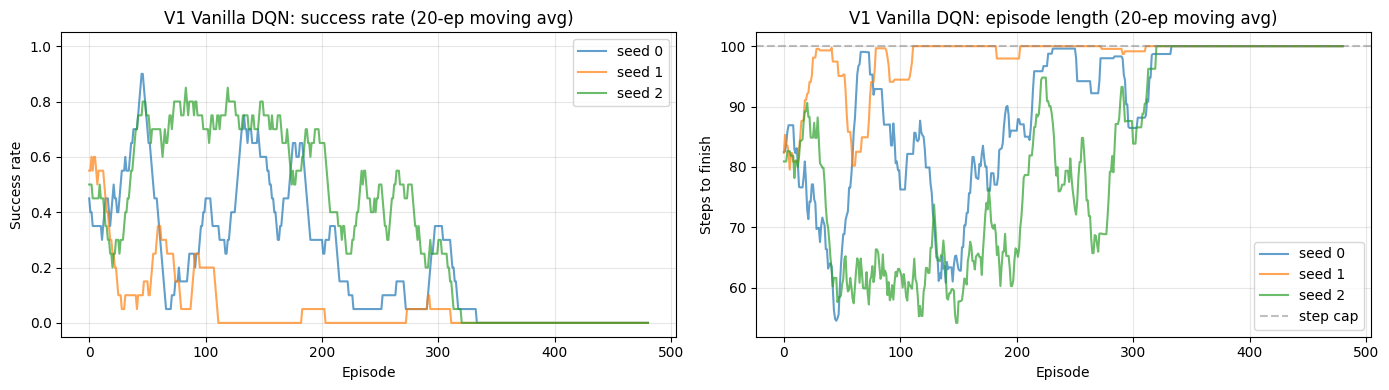

In [11]:
def smooth(arr, window=20):
    """Moving average for plotting noisy per-episode data."""
    if len(arr) < window:
        return arr
    return np.convolve(arr, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# left: success rate over time (smoothed) for each seed
for i, r in enumerate(v1_runs):
    s = smooth(r['successes'], window=20)
    axes[0].plot(s, alpha=0.7, label=f'seed {i}')
axes[0].set_title('V1 Vanilla DQN: success rate (20-ep moving avg)')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Success rate')
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend()
axes[0].grid(alpha=0.3)

# right: episode length over time
for i, r in enumerate(v1_runs):
    s = smooth(r['lengths'], window=20)
    axes[1].plot(s, alpha=0.7, label=f'seed {i}')
axes[1].set_title('V1 Vanilla DQN: episode length (20-ep moving avg)')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Steps to finish')
axes[1].axhline(MAX_STEPS, color='gray', linestyle='--', alpha=0.5, label='step cap')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## V1 diagnosis

The three seeds tell the same story: partial learning during the early epsilon-high phase (13-18% success around episode 100), followed by a steady collapse to 0% by episode 300. Episode length saturates at the 100-step cap.

Identical failure across seeds means this is structural, not bad luck. Vanilla DQN trains on highly correlated consecutive transitions and chases a target produced by the same network it is updating, so once the policy drifts into a region where it can't find the pallet, it has no way to recover.

V2 addresses the correlation problem with an experience replay buffer.

## V2: DQN with Experience Replay

We add replay buffer. Each transition is stored, and at each step we sample a random batch from the buffer and train on that. The target is still computed by the same network, so the moving target problem from V1 remains.

In [12]:
class ReplayBuffer:
    """
    Fixed-size buffer that stores transitions and samples random batches.
    Uses deque so old transitions are dropped automatically when full.
    """
    def __init__(self, capacity):
        self.buf = deque(maxlen=capacity)

    def push(self, s, a, r, ns, done):
        self.buf.append((s, a, r, ns, done))

    def sample(self, batch_size):
        batch = random.sample(self.buf, batch_size)
        # unzip into separate lists
        s, a, r, ns, d = zip(*batch)
        return s, a, r, ns, d

    def __len__(self):
        return len(self.buf)


# quick check that it works
buf = ReplayBuffer(100)
buf.push(np.zeros(2050), 0, 1.0, np.zeros(2050), False)
print(f"Buffer size after 1 push: {len(buf)}")

Buffer size after 1 push: 1


In [13]:
# new hyperparameters specific to V2
BUFFER_SIZE = 10000       # max transitions kept in memory
BATCH_SIZE = 64           # transitions sampled per gradient step
MIN_BUFFER = 256          # don't train until buffer has at least this many

def train_v2(env, seed=0, episodes=EPISODES, verbose=True):
    """
    DQN with experience replay. Same as V1 but trains on batches sampled
    from a buffer instead of the last transition.
    """
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n
    net = QNetwork(state_dim, action_dim).to(device)
    opt = optim.Adam(net.parameters(), lr=LR)
    buffer = ReplayBuffer(BUFFER_SIZE)

    eps = EPS_START
    successes, lengths, total_rewards = [], [], []

    for ep in range(episodes):
        obs, _ = env.reset()
        ep_reward = 0.0

        for t in range(MAX_STEPS):
            # epsilon-greedy as before
            if random.random() < eps:
                action = random.randint(0, action_dim - 1)
            else:
                with torch.no_grad():
                    s = torch.from_numpy(obs).float().unsqueeze(0).to(device)
                    action = int(net(s).argmax(dim=1).item())

            next_obs, reward, term, trunc, _ = env.step(action)
            ep_reward += reward
            done = term or trunc

            # store the transition instead of training on it directly
            buffer.push(obs, action, reward, next_obs, done)
            obs = next_obs

            # only train once we have enough transitions to sample a batch
            if len(buffer) >= MIN_BUFFER:
                # sample random batch and convert to tensors
                bs, ba, br, bns, bd = buffer.sample(BATCH_SIZE)
                bs = torch.from_numpy(np.array(bs)).float().to(device)
                bns = torch.from_numpy(np.array(bns)).float().to(device)
                ba = torch.tensor(ba, device=device).unsqueeze(1)
                br = torch.tensor(br, dtype=torch.float32, device=device).unsqueeze(1)
                bd = torch.tensor(bd, dtype=torch.float32, device=device).unsqueeze(1)

                # same Bellman update as V1, just over a batch
                q_pred = net(bs).gather(1, ba)
                with torch.no_grad():
                    q_next = net(bns).max(dim=1, keepdim=True)[0]
                    q_target = br + GAMMA * q_next * (1 - bd)

                loss = F.mse_loss(q_pred, q_target)
                opt.zero_grad()
                loss.backward()
                opt.step()

            if done:
                break

        successes.append(int(term))
        lengths.append(t + 1)
        total_rewards.append(ep_reward)
        eps = max(EPS_END, eps * EPS_DECAY)

        if verbose and (ep + 1) % 100 == 0:
            recent = np.mean(successes[-100:])
            print(f"  ep {ep+1:4d} | last-100 success: {recent:.2%} | eps: {eps:.3f}")

    return {
        'successes': np.array(successes),
        'lengths': np.array(lengths),
        'rewards': np.array(total_rewards),
        'net': net,
    }

In [14]:
print("Training V2 DQN + replay x3 seeds...")
v2_runs = []
for seed in [0, 1, 2]:
    print(f"\nSeed {seed}:")
    t0 = time.time()
    result = train_v2(env, seed=seed)
    print(f"  done in {time.time() - t0:.1f}s")
    v2_runs.append(result)

print("\nFinal 100-episode success rates per seed:")
for i, r in enumerate(v2_runs):
    final_succ = r['successes'][-100:].mean()
    print(f"  Seed {i}: {final_succ:.2%}")

Training V2 DQN + replay x3 seeds...

Seed 0:
  ep  100 | last-100 success: 77.00% | eps: 0.606
  ep  200 | last-100 success: 71.00% | eps: 0.367
  ep  300 | last-100 success: 100.00% | eps: 0.222
  ep  400 | last-100 success: 99.00% | eps: 0.135
  ep  500 | last-100 success: 100.00% | eps: 0.082
  done in 56.4s

Seed 1:
  ep  100 | last-100 success: 91.00% | eps: 0.606
  ep  200 | last-100 success: 73.00% | eps: 0.367
  ep  300 | last-100 success: 53.00% | eps: 0.222
  ep  400 | last-100 success: 92.00% | eps: 0.135
  ep  500 | last-100 success: 22.00% | eps: 0.082
  done in 88.6s

Seed 2:
  ep  100 | last-100 success: 65.00% | eps: 0.606
  ep  200 | last-100 success: 82.00% | eps: 0.367
  ep  300 | last-100 success: 71.00% | eps: 0.222
  ep  400 | last-100 success: 8.00% | eps: 0.135
  ep  500 | last-100 success: 0.00% | eps: 0.082
  done in 116.1s

Final 100-episode success rates per seed:
  Seed 0: 100.00%
  Seed 1: 22.00%
  Seed 2: 0.00%


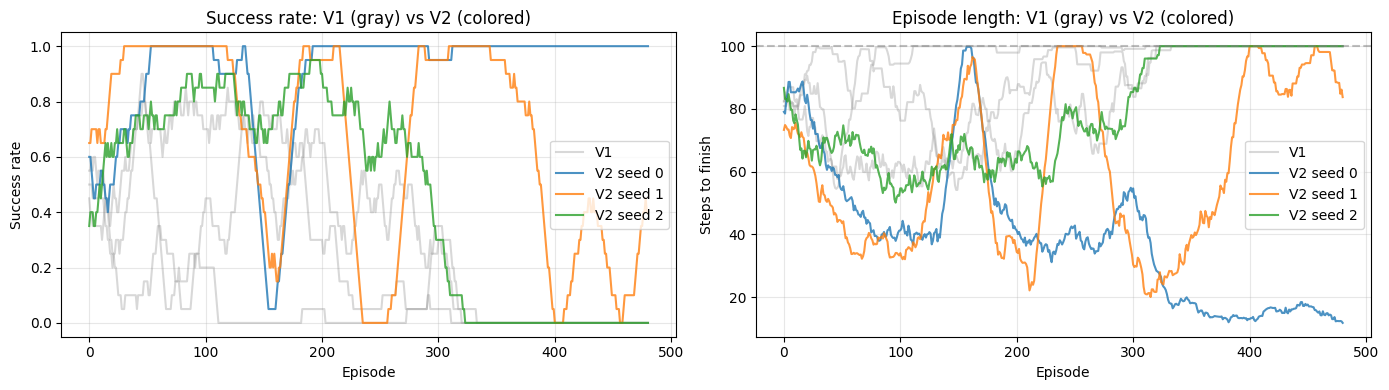

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# left success rate, V1 in muted colors, V2 in bold
for i, r in enumerate(v1_runs):
    s = smooth(r['successes'], window=20)
    axes[0].plot(s, alpha=0.3, color='gray', label='V1' if i == 0 else None)
for i, r in enumerate(v2_runs):
    s = smooth(r['successes'], window=20)
    axes[0].plot(s, alpha=0.8, label=f'V2 seed {i}')
axes[0].set_title('Success rate: V1 (gray) vs V2 (colored)')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Success rate')
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend()
axes[0].grid(alpha=0.3)

# right: episode length comparison
for i, r in enumerate(v1_runs):
    s = smooth(r['lengths'], window=20)
    axes[1].plot(s, alpha=0.3, color='gray', label='V1' if i == 0 else None)
for i, r in enumerate(v2_runs):
    s = smooth(r['lengths'], window=20)
    axes[1].plot(s, alpha=0.8, label=f'V2 seed {i}')
axes[1].set_title('Episode length: V1 (gray) vs V2 (colored)')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Steps to finish')
axes[1].axhline(MAX_STEPS, color='gray', linestyle='--', alpha=0.5)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## V2 diagnosis

Replay gave a striking but unstable result. One seed converged almost perfectly. The other two collapsed like V1 partial learning and then complete failure

The buffer breaks correlation between consecutive transitions, which is why the lucky seed could lock in a good policy instead of forgetting it. But targets are still computed by the network being trained, so when early exploration fails to find the pallet, the network drifts on bad targets and never recovers, basically the same failure mode as V1.


## V3: DQN + Replay + Target Network

Replay buffer from V2 and adds a target network, frozen copy of the policy network used to compute the Bellman target. The copy is synced from the policy network every N episodes, so the target stays stable in between updates instead of drifting at every gradient step. Is reduced variance across seeds compared to V2.

In [16]:
# new hyperparameter, how often we copy policy net weights into target net
TARGET_UPDATE = 10  # every 10 episodes

def train_v3(env, seed=0, episodes=EPISODES, verbose=True):
    """
    DQN with experience replay AND a target network. The target net is a
    frozen copy of the policy net, synced every TARGET_UPDATE episodes.
    """
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    # two networks now: policy is trained, target is frozen between syncs
    policy_net = QNetwork(state_dim, action_dim).to(device)
    target_net = QNetwork(state_dim, action_dim).to(device)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()  # we never train the target net directly

    opt = optim.Adam(policy_net.parameters(), lr=LR)
    buffer = ReplayBuffer(BUFFER_SIZE)

    eps = EPS_START
    successes, lengths, total_rewards = [], [], []

    for ep in range(episodes):
        obs, _ = env.reset()
        ep_reward = 0.0

        for t in range(MAX_STEPS):
            # epsilon-greedy uses the policy net (the one we are training)
            if random.random() < eps:
                action = random.randint(0, action_dim - 1)
            else:
                with torch.no_grad():
                    s = torch.from_numpy(obs).float().unsqueeze(0).to(device)
                    action = int(policy_net(s).argmax(dim=1).item())

            next_obs, reward, term, trunc, _ = env.step(action)
            ep_reward += reward
            done = term or trunc

            buffer.push(obs, action, reward, next_obs, done)
            obs = next_obs

            if len(buffer) >= MIN_BUFFER:
                bs, ba, br, bns, bd = buffer.sample(BATCH_SIZE)
                bs = torch.from_numpy(np.array(bs)).float().to(device)
                bns = torch.from_numpy(np.array(bns)).float().to(device)
                ba = torch.tensor(ba, device=device).unsqueeze(1)
                br = torch.tensor(br, dtype=torch.float32, device=device).unsqueeze(1)
                bd = torch.tensor(bd, dtype=torch.float32, device=device).unsqueeze(1)

                # current Q-values from the policy net (the one we train)
                q_pred = policy_net(bs).gather(1, ba)

                # KEY DIFFERENCE FROM V2: target uses the TARGET net, not policy
                # this means the target is stable between syncs
                with torch.no_grad():
                    q_next = target_net(bns).max(dim=1, keepdim=True)[0]
                    q_target = br + GAMMA * q_next * (1 - bd)

                loss = F.mse_loss(q_pred, q_target)
                opt.zero_grad()
                loss.backward()
                opt.step()

            if done:
                break

        successes.append(int(term))
        lengths.append(t + 1)
        total_rewards.append(ep_reward)
        eps = max(EPS_END, eps * EPS_DECAY)

        # sync target net periodically
        if (ep + 1) % TARGET_UPDATE == 0:
            target_net.load_state_dict(policy_net.state_dict())

        if verbose and (ep + 1) % 100 == 0:
            recent = np.mean(successes[-100:])
            print(f"  ep {ep+1:4d} | last-100 success: {recent:.2%} | eps: {eps:.3f}")

    return {
        'successes': np.array(successes),
        'lengths': np.array(lengths),
        'rewards': np.array(total_rewards),
        'net': policy_net,  # we save the policy net, target was just for training
    }

In [17]:
print("Training V3 DQN + replay + target net x3 seeds...")
v3_runs = []
for seed in [0, 1, 2]:
    print(f"\nSeed {seed}:")
    t0 = time.time()
    result = train_v3(env, seed=seed)
    print(f"  done in {time.time() - t0:.1f}s")
    v3_runs.append(result)

print("\nFinal 100-episode success rates per seed:")
for i, r in enumerate(v3_runs):
    final_succ = r['successes'][-100:].mean()
    print(f"  Seed {i}: {final_succ:.2%}")

Training V3 DQN + replay + target net x3 seeds...

Seed 0:
  ep  100 | last-100 success: 85.00% | eps: 0.606
  ep  200 | last-100 success: 84.00% | eps: 0.367
  ep  300 | last-100 success: 11.00% | eps: 0.222
  ep  400 | last-100 success: 56.00% | eps: 0.135
  ep  500 | last-100 success: 100.00% | eps: 0.082
  done in 76.3s

Seed 1:
  ep  100 | last-100 success: 90.00% | eps: 0.606
  ep  200 | last-100 success: 94.00% | eps: 0.367
  ep  300 | last-100 success: 100.00% | eps: 0.222
  ep  400 | last-100 success: 100.00% | eps: 0.135
  ep  500 | last-100 success: 71.00% | eps: 0.082
  done in 38.6s

Seed 2:
  ep  100 | last-100 success: 58.00% | eps: 0.606
  ep  200 | last-100 success: 70.00% | eps: 0.367
  ep  300 | last-100 success: 40.00% | eps: 0.222
  ep  400 | last-100 success: 91.00% | eps: 0.135
  ep  500 | last-100 success: 100.00% | eps: 0.082
  done in 72.1s

Final 100-episode success rates per seed:
  Seed 0: 100.00%
  Seed 1: 71.00%
  Seed 2: 100.00%


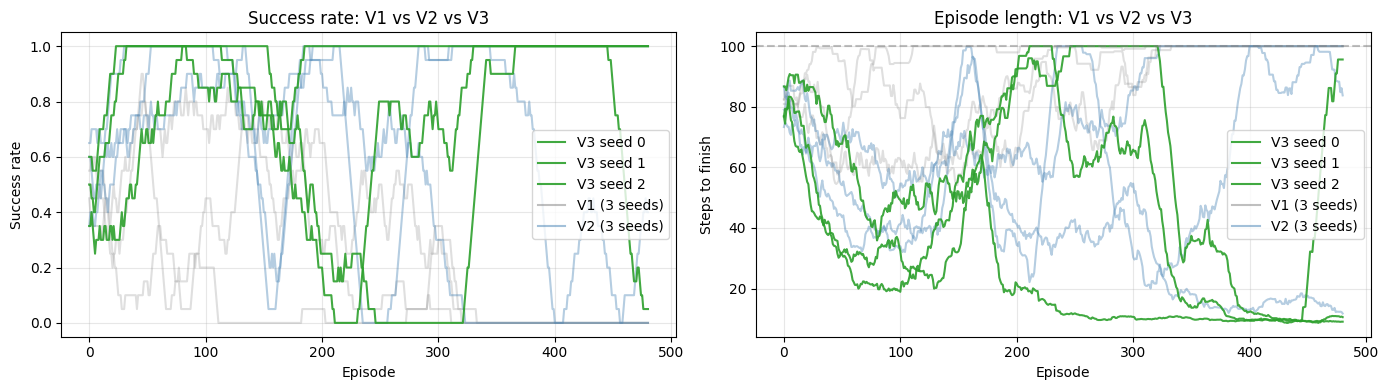


--- Final performance (last 100 episodes) ---
Variant     Mean succ   Std succ   Mean len
V1              0.00%      0.00%      100.0
V2             40.67%     42.91%       68.9
V3             90.33%     13.67%       18.4


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# success rate, V1 muted, V2 medium, V3 bold
for r in v1_runs:
    axes[0].plot(smooth(r['successes'], 20), alpha=0.25, color='gray')
for r in v2_runs:
    axes[0].plot(smooth(r['successes'], 20), alpha=0.4, color='steelblue')
for i, r in enumerate(v3_runs):
    axes[0].plot(smooth(r['successes'], 20), alpha=0.9, color='C2',
                 label=f'V3 seed {i}')
# add proxy labels for V1 and V2 in legend
axes[0].plot([], [], color='gray', alpha=0.5, label='V1 (3 seeds)')
axes[0].plot([], [], color='steelblue', alpha=0.5, label='V2 (3 seeds)')
axes[0].set_title('Success rate: V1 vs V2 vs V3')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Success rate')
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend(loc='center right')
axes[0].grid(alpha=0.3)

# episode length
for r in v1_runs:
    axes[1].plot(smooth(r['lengths'], 20), alpha=0.25, color='gray')
for r in v2_runs:
    axes[1].plot(smooth(r['lengths'], 20), alpha=0.4, color='steelblue')
for i, r in enumerate(v3_runs):
    axes[1].plot(smooth(r['lengths'], 20), alpha=0.9, color='C2',
                 label=f'V3 seed {i}')
axes[1].plot([], [], color='gray', alpha=0.5, label='V1 (3 seeds)')
axes[1].plot([], [], color='steelblue', alpha=0.5, label='V2 (3 seeds)')
axes[1].axhline(MAX_STEPS, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Episode length: V1 vs V2 vs V3')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Steps to finish')
axes[1].legend(loc='center right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# summary table of final 100-episode performance
print("\n--- Final performance (last 100 episodes) ---")
print(f"{'Variant':<10} {'Mean succ':>10} {'Std succ':>10} {'Mean len':>10}")
for name, runs in [('V1', v1_runs), ('V2', v2_runs), ('V3', v3_runs)]:
    succs = [r['successes'][-100:].mean() for r in runs]
    lens = [r['lengths'][-100:].mean() for r in runs]
    print(f"{name:<10} {np.mean(succs):>10.2%} {np.std(succs):>10.2%} {np.mean(lens):>10.1f}")

## Reward ablation

we implemented a large positive reward at the goal, a step penalty for efficiency, and a wall bump penalty. We now ask which of those components actually matter, and whether adding a positive shaping signal at signs helps the agent learn faster.

We define four reward variants and train V3 on each, with three seeds, on the same grid.

- R1: only +10 at the goal (sparse reward).
- R2: +10 at goal, -0.05 step penalty.
- R3: +10 at goal, -0.05 step, -1 wall (the "rea" version)
- R4: R3 plus +0.5 when the agent stands on a sign tile. Interesting for a 50x50 grid

In [19]:
# Each variant is a subclass overriding _calculate_reward.
# We don't touch WarehouseEnv.py for these because they're temporary
# experiment variants. The winner of this ablation will replace the
# provisional reward in the file afterwards.

class WarehouseEnvR1(WarehouseEnv):
    """Sparse: only the goal gives signal."""
    def _calculate_reward(self, prev_pos, current_pos, terminated, hit_wall):
        if terminated:
            return 10.0
        return 0.0


class WarehouseEnvR2(WarehouseEnv):
    """Goal + step penalty for efficiency."""
    def _calculate_reward(self, prev_pos, current_pos, terminated, hit_wall):
        if terminated:
            return 10.0
        return -0.05


class WarehouseEnvR3(WarehouseEnv):
    """Full reward (goal, step, wall). Same as the provisional in the file."""
    def _calculate_reward(self, prev_pos, current_pos, terminated, hit_wall):
        if terminated:
            return 10.0
        if hit_wall:
            return -1.0
        return -0.05


class WarehouseEnvR4(WarehouseEnvR3):
    """R3 plus a positive bonus when standing on a sign tile."""
    def _calculate_reward(self, prev_pos, current_pos, terminated, hit_wall):
        # base reward from R3
        r = super()._calculate_reward(prev_pos, current_pos, terminated, hit_wall)
        # check current tile, add bonus if it's a sign (id 3)
        # only if the agent actually moved (no bonus for trying to enter a wall)
        if not terminated and not hit_wall:
            current_tile = self.grid_map[current_pos[1], current_pos[0]]
            if current_tile == 3:
                r += 0.5
        return r


# quick sanity check that all four subclasses build and step without crashing
for name, cls in [('R1', WarehouseEnvR1), ('R2', WarehouseEnvR2),
                   ('R3', WarehouseEnvR3), ('R4', WarehouseEnvR4)]:
    test_env = cls(grid_map=GRID, embeddings_dict=emb)
    test_env.reset()
    _, r, _, _, _ = test_env.step(3)  # right
    print(f"{name}: step right reward = {r}")

R1: step right reward = 0.0
R2: step right reward = -0.05
R3: step right reward = -0.05
R4: step right reward = -0.05


In [20]:
# we reuse train_v3 since we decided V3 is the variant we benchmark on
# only the env class changes; everything else (network, hyperparams, loop) stays
print("Running reward ablation: 4 variants x 3 seeds...")

reward_runs = {}  # dict: 'R1' -> list of 3 result dicts

for name, cls in [('R1', WarehouseEnvR1), ('R2', WarehouseEnvR2),
                   ('R3', WarehouseEnvR3), ('R4', WarehouseEnvR4)]:
    print(f"\n=== {name} ===")
    runs = []
    for seed in [0, 1, 2]:
        # build a fresh env of the right class for each seed
        env_r = cls(grid_map=GRID, embeddings_dict=emb)
        print(f"  Seed {seed}:")
        t0 = time.time()
        result = train_v3(env_r, seed=seed, verbose=False)
        final = result['successes'][-100:].mean()
        print(f"    done in {time.time() - t0:.1f}s | final 100-ep success: {final:.2%}")
        runs.append(result)
    reward_runs[name] = runs

print("\nAblation done.")

Running reward ablation: 4 variants x 3 seeds...

=== R1 ===
  Seed 0:
    done in 100.0s | final 100-ep success: 76.00%
  Seed 1:
    done in 58.3s | final 100-ep success: 100.00%
  Seed 2:
    done in 116.3s | final 100-ep success: 51.00%

=== R2 ===
  Seed 0:
    done in 67.4s | final 100-ep success: 100.00%
  Seed 1:
    done in 91.5s | final 100-ep success: 92.00%
  Seed 2:
    done in 106.5s | final 100-ep success: 38.00%

=== R3 ===
  Seed 0:
    done in 74.4s | final 100-ep success: 100.00%
  Seed 1:
    done in 38.0s | final 100-ep success: 71.00%
  Seed 2:
    done in 71.7s | final 100-ep success: 100.00%

=== R4 ===
  Seed 0:
    done in 128.8s | final 100-ep success: 1.00%
  Seed 1:
    done in 125.3s | final 100-ep success: 0.00%
  Seed 2:
    done in 129.9s | final 100-ep success: 1.00%

Ablation done.


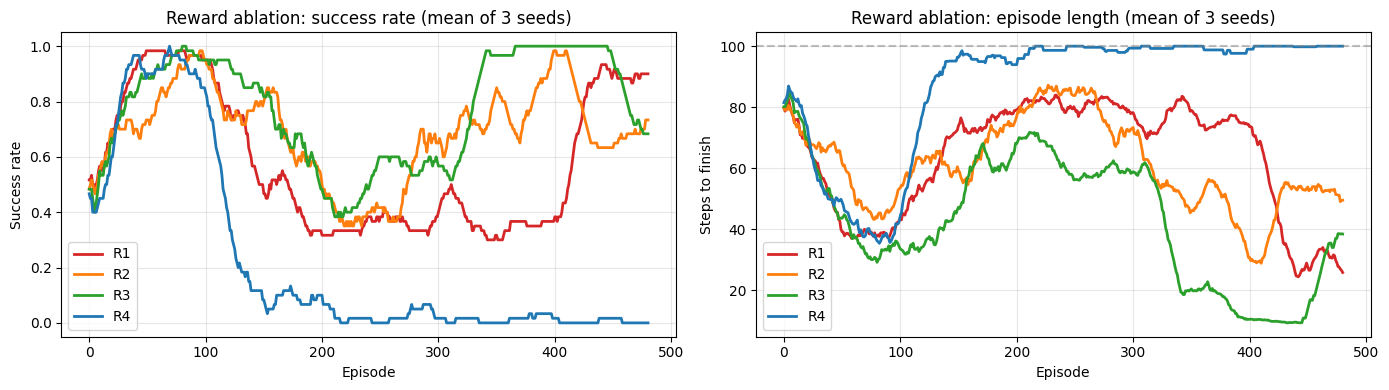


--- Final performance by reward variant (last 100 episodes) ---
Variant   Mean succ   Std succ   Mean len
R1           75.67%     20.01%       41.8
R2           76.67%     27.54%       45.7
R3           90.33%     13.67%       18.4
R4            0.67%      0.47%       99.8


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# colors per variant
colors = {'R1': 'tab:red', 'R2': 'tab:orange', 'R3': 'tab:green', 'R4': 'tab:blue'}

# left: success rate, average across seeds for clarity
for name, runs in reward_runs.items():
    # stack the 3 seeds' success arrays and average per-episode
    succ_stack = np.stack([r['successes'] for r in runs])
    mean_succ = smooth(succ_stack.mean(axis=0), window=20)
    axes[0].plot(mean_succ, color=colors[name], label=name, linewidth=2)
axes[0].set_title('Reward ablation: success rate (mean of 3 seeds)')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Success rate')
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend()
axes[0].grid(alpha=0.3)

# right: episode length
for name, runs in reward_runs.items():
    len_stack = np.stack([r['lengths'] for r in runs])
    mean_len = smooth(len_stack.mean(axis=0), window=20)
    axes[1].plot(mean_len, color=colors[name], label=name, linewidth=2)
axes[1].axhline(MAX_STEPS, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Reward ablation: episode length (mean of 3 seeds)')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Steps to finish')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# summary table
print("\n--- Final performance by reward variant (last 100 episodes) ---")
print(f"{'Variant':<8} {'Mean succ':>10} {'Std succ':>10} {'Mean len':>10}")
for name, runs in reward_runs.items():
    succs = [r['successes'][-100:].mean() for r in runs]
    lens = [r['lengths'][-100:].mean() for r in runs]
    print(f"{name:<8} {np.mean(succs):>10.2%} {np.std(succs):>10.2%} {np.mean(lens):>10.1f}")